In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# BELGIUM - STEP 1
# Rebuild BE 2007/2009 preparation datasets
# - recompute eq_income
# - create age_group
# - keep target model variables
# - output side-by-side diagnostics by year
# =========================================================

base = Path("/content/drive/MyDrive/belgium")
files = {
    "BE_2007": base / "BE_2007_master_clean.csv",
    "BE_2009": base / "BE_2009_master_clean.csv",
}

for k, v in files.items():
    print(f"{k}: exists = {v.exists()} | path = {v}")

# 正式模型口径：age 不直接入模，改成 age_group
model_vars_with_y = [
    "HY020", "HX050", "PB040",
    "PB150", "PB220A", "DB040",
    "PE040", "PH010",
    "economic_status", "PL040", "PL050", "HH030", "HS040",
    "age"
]

special_codes = [-1, -2, -3, -4, -5, -6, -7, -8, -9]

num_cols = [
    "HY020", "HX050", "PB040", "age",
    "PE040", "PH010", "economic_status", "PL040", "HH030", "HS040"
]

prepared = {}
summary_rows = []
missing_tables = []
agegroup_tables = []

for dataset_name, path in files.items():
    print("\n" + "=" * 90)
    print(f"PROCESSING {dataset_name}")
    print("=" * 90)

    df = pd.read_csv(path, low_memory=False)

    missing_cols = [c for c in model_vars_with_y if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{dataset_name} missing columns: {missing_cols}")

    work = df[model_vars_with_y].copy()

    # numeric columns -> numeric, special codes -> NaN
    for col in num_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")
        work.loc[work[col].isin(special_codes), col] = np.nan

    # PL050 保持分类变量；特殊码转缺失
    work["PL050"] = work["PL050"].astype("string")
    work.loc[work["PL050"].isin([str(x) for x in special_codes]), "PL050"] = pd.NA

    # recompute eq_income
    work["eq_income"] = np.where(
        work["HY020"].notna() & work["HX050"].notna() & (work["HX050"] > 0),
        work["HY020"] / work["HX050"],
        np.nan
    )

    # create age_group
    work["age_group"] = pd.cut(
        work["age"],
        bins=[0, 14, 24, 54, 64, np.inf],
        labels=["0_14", "15_24", "25_54", "55_64", "65_plus"],
        include_lowest=True,
        right=True
    )

    keep_cols = [
        "eq_income", "PB040",
        "PB150", "PB220A", "DB040",
        "age", "age_group",
        "PE040", "PH010",
        "economic_status", "PL040", "PL050", "HH030", "HS040"
    ]
    work = work[keep_cols].copy()
    prepared[dataset_name] = work

    summary_rows.append({
        "dataset": dataset_name,
        "year": int(dataset_name.split("_")[1]),
        "n_raw": len(df),
        "eq_income_missing": int(work["eq_income"].isna().sum()),
        "eq_income_le_0": int((work["eq_income"] <= 0).sum()),
        "PB040_missing": int(work["PB040"].isna().sum()),
        "PB040_le_0": int((work["PB040"] <= 0).sum()),
        "age_missing": int(work["age"].isna().sum()),
        "age_group_missing": int(work["age_group"].isna().sum())
    })

    miss = work[
        ["eq_income", "PB040", "PB150", "PB220A", "DB040",
         "age_group", "PE040", "PH010",
         "economic_status", "PL040", "PL050", "HH030", "HS040"]
    ].isna().sum().rename(dataset_name)
    missing_tables.append(miss)

    ag = work["age_group"].value_counts(dropna=False).sort_index().rename(dataset_name)
    agegroup_tables.append(ag)

    print("shape after preparation:", work.shape)
    print("eq_income missing:", work["eq_income"].isna().sum())
    print("eq_income <= 0:", (work["eq_income"] <= 0).sum())
    print("age_group counts:")
    print(work["age_group"].value_counts(dropna=False).sort_index())

# combined outputs
summary_df = pd.DataFrame(summary_rows).sort_values("year").reset_index(drop=True)

missing_compare = pd.concat(missing_tables, axis=1)
missing_compare = missing_compare[["BE_2007", "BE_2009"]]

agegroup_compare = pd.concat(agegroup_tables, axis=1)
agegroup_compare = agegroup_compare[["BE_2007", "BE_2009"]]

print("\n" + "=" * 90)
print("COMBINED SUMMARY BY YEAR")
print("=" * 90)
print(summary_df)

print("\n" + "=" * 90)
print("MISSING COUNTS COMPARISON BY YEAR")
print("=" * 90)
print(missing_compare)

print("\n" + "=" * 90)
print("AGE_GROUP DISTRIBUTION BY YEAR")
print("=" * 90)
print(agegroup_compare)

# save outputs
outdir = Path("/content/drive/MyDrive/belgium_results")
outdir.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(outdir / "BE_2007_2009_step1_summary.csv", index=False)
missing_compare.to_csv(outdir / "BE_2007_2009_step1_missing_compare.csv")
agegroup_compare.to_csv(outdir / "BE_2007_2009_step1_agegroup_compare.csv")

prepared["BE_2007"].to_csv(outdir / "BE_2007_prepared_with_eqincome_agegroup.csv", index=False)
prepared["BE_2009"].to_csv(outdir / "BE_2009_prepared_with_eqincome_agegroup.csv", index=False)

print("\nSaved files:")
print(outdir / "BE_2007_2009_step1_summary.csv")
print(outdir / "BE_2007_2009_step1_missing_compare.csv")
print(outdir / "BE_2007_2009_step1_agegroup_compare.csv")
print(outdir / "BE_2007_prepared_with_eqincome_agegroup.csv")
print(outdir / "BE_2009_prepared_with_eqincome_agegroup.csv")

BE_2007: exists = True | path = /content/drive/MyDrive/belgium/BE_2007_master_clean.csv
BE_2009: exists = True | path = /content/drive/MyDrive/belgium/BE_2009_master_clean.csv

PROCESSING BE_2007
shape after preparation: (11974, 14)
eq_income missing: 2
eq_income <= 0: 778
age_group counts:
age_group
0_14          0
15_24      1411
25_54      6147
55_64      1823
65_plus    2593
Name: count, dtype: int64

PROCESSING BE_2009
shape after preparation: (11559, 14)
eq_income missing: 7
eq_income <= 0: 637
age_group counts:
age_group
0_14          0
15_24      1430
25_54      5830
55_64      1804
65_plus    2495
Name: count, dtype: int64

COMBINED SUMMARY BY YEAR
   dataset  year  n_raw  eq_income_missing  eq_income_le_0  PB040_missing  \
0  BE_2007  2007  11974                  2             778              0   
1  BE_2009  2009  11559                  7             637              0   

   PB040_le_0  age_missing  age_group_missing  
0           0            0                  0  
1     

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# BELGIUM - STEP 2
# Build ONE common complete-case sample per year
# based on FULL model covariates
# Then both extended model and full model will use the SAME rows
# =========================================================

input_dir = Path("/content/drive/MyDrive/belgium_results")
output_dir = Path("/content/drive/MyDrive/belgium_results")
output_dir.mkdir(parents=True, exist_ok=True)

files = {
    "BE_2007": input_dir / "BE_2007_prepared_with_eqincome_agegroup.csv",
    "BE_2009": input_dir / "BE_2009_prepared_with_eqincome_agegroup.csv",
}

# age 不再进模型，改成 age_group
# 共同样本按 full model 所需全部变量删缺失
full_covariates_with_y = [
    "eq_income", "PB040",
    "PB150", "PB220A", "DB040",
    "age_group", "PE040", "PH010",
    "economic_status", "PL040", "PL050", "HH030", "HS040"
]

all_summary = []
all_cc = []

for dataset_name, path in files.items():
    print("\n" + "=" * 90)
    print(f"BUILDING COMMON COMPLETE-CASE SAMPLE: {dataset_name}")
    print("=" * 90)

    df = pd.read_csv(path, low_memory=False)

    d = df[full_covariates_with_y].copy()

    n_prepared = len(d)
    print("n_prepared:", n_prepared)

    # 先筛 eq_income 和 PB040 有效
    d = d[
        d["eq_income"].notna() &
        (d["eq_income"] > 0) &
        d["PB040"].notna() &
        (d["PB040"] > 0)
    ].copy()

    n_after_income_weight = len(d)
    print("n_after_valid_eq_income_and_weight:", n_after_income_weight)

    # full complete-case：任何 covariate 缺失就删
    d_cc = d.dropna().copy()

    n_common_cc = len(d_cc)
    print("n_common_complete_case:", n_common_cc)
    print("rows_dropped_at_complete_case_step:", n_after_income_weight - n_common_cc)

    print("\nMissing counts AFTER common complete-case:")
    print(d_cc.isna().sum())

    # 年份标签
    d_cc["dataset"] = dataset_name
    d_cc["year"] = int(dataset_name.split("_")[1])

    save_path = output_dir / f"{dataset_name}_common_cc_for_extended_and_full.csv"
    d_cc.to_csv(save_path, index=False)

    print("\nSaved common sample to:")
    print(save_path)

    all_cc.append(d_cc)

    all_summary.append(pd.DataFrame({
        "dataset": [dataset_name],
        "year": [int(dataset_name.split("_")[1])],
        "n_prepared": [n_prepared],
        "n_after_valid_eq_income_and_weight": [n_after_income_weight],
        "n_common_complete_case": [n_common_cc],
        "rows_dropped_at_complete_case_step": [n_after_income_weight - n_common_cc]
    }))

summary_df = pd.concat(all_summary, ignore_index=True).sort_values("year").reset_index(drop=True)
combined_cc = pd.concat(all_cc, ignore_index=True).sort_values("year").reset_index(drop=True)

print("\n" + "=" * 90)
print("COMMON SAMPLE SUMMARY BY YEAR")
print("=" * 90)
print(summary_df)

summary_path = output_dir / "BE_2007_2009_common_cc_summary.csv"
combined_path = output_dir / "BE_2007_2009_common_cc_combined.csv"

summary_df.to_csv(summary_path, index=False)
combined_cc.to_csv(combined_path, index=False)

print("\nSaved summary to:")
print(summary_path)

print("\nSaved combined common sample to:")
print(combined_path)


BUILDING COMMON COMPLETE-CASE SAMPLE: BE_2007
n_prepared: 11974
n_after_valid_eq_income_and_weight: 11194
n_common_complete_case: 7325
rows_dropped_at_complete_case_step: 3869

Missing counts AFTER common complete-case:
eq_income          0
PB040              0
PB150              0
PB220A             0
DB040              0
age_group          0
PE040              0
PH010              0
economic_status    0
PL040              0
PL050              0
HH030              0
HS040              0
dtype: int64

Saved common sample to:
/content/drive/MyDrive/belgium_results/BE_2007_common_cc_for_extended_and_full.csv

BUILDING COMMON COMPLETE-CASE SAMPLE: BE_2009
n_prepared: 11559
n_after_valid_eq_income_and_weight: 10915
n_common_complete_case: 7789
rows_dropped_at_complete_case_step: 3126

Missing counts AFTER common complete-case:
eq_income          0
PB040              0
PB150              0
PB220A             0
DB040              0
age_group          0
PE040              0
PH010            

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# BELGIUM - STEP 3
# Fix and validate one reference category for every covariate
# =========================================================

input_dir = Path("/content/drive/MyDrive/belgium_results")

files = {
    "BE_2007": input_dir / "BE_2007_common_cc_for_extended_and_full.csv",
    "BE_2009": input_dir / "BE_2009_common_cc_for_extended_and_full.csv",
}

covariates = [
    "PB150", "PB220A", "DB040", "age_group", "PE040", "PH010",
    "economic_status", "PL040", "PL050", "HH030", "HS040"
]

# 先按 Belgium 的常规候选 reference 检查
# age_group 不包含 0_14，因为它是空组
reference_map = {
    "PB150": "1",
    "PB220A": "BE",
    "DB040": "BE1",
    "age_group": "25_54",
    "PE040": "1.0",
    "PH010": "2.0",
    "economic_status": "1.0",
    "PL040": "3.0",
    "PL050": "9",
    "HH030": "6.0",
    "HS040": "1.0"
}

d2007 = pd.read_csv(files["BE_2007"], low_memory=False)
d2009 = pd.read_csv(files["BE_2009"], low_memory=False)

for col in covariates:
    d2007[col] = d2007[col].astype("string")
    d2009[col] = d2009[col].astype("string")

rows = []

for var in covariates:
    ref = reference_map[var]

    levels_2007 = sorted(d2007[var].dropna().unique().tolist())
    levels_2009 = sorted(d2009[var].dropna().unique().tolist())

    ref_in_2007 = ref in levels_2007
    ref_in_2009 = ref in levels_2009

    rows.append({
        "variable": var,
        "reference": ref,
        "reference_in_2007": ref_in_2007,
        "reference_in_2009": ref_in_2009,
        "n_levels_2007": len(levels_2007),
        "n_levels_2009": len(levels_2009),
        "levels_2007": " | ".join(levels_2007),
        "levels_2009": " | ".join(levels_2009)
    })

reference_summary = pd.DataFrame(rows)

print("\n" + "=" * 100)
print("REFERENCE SUMMARY")
print("=" * 100)
print(reference_summary[[
    "variable", "reference", "reference_in_2007", "reference_in_2009",
    "n_levels_2007", "n_levels_2009"
]])

invalid = reference_summary[
    (~reference_summary["reference_in_2007"]) |
    (~reference_summary["reference_in_2009"])
]

print("\n" + "=" * 100)
print("INVALID REFERENCES (should be empty)")
print("=" * 100)
print(invalid)

out_path = input_dir / "BE_2007_2009_reference_summary.csv"
reference_summary.to_csv(out_path, index=False)

print("\nSaved reference summary to:")
print(out_path)


REFERENCE SUMMARY
           variable reference  reference_in_2007  reference_in_2009  \
0             PB150         1               True               True   
1            PB220A        BE               True               True   
2             DB040       BE1              False              False   
3         age_group     25_54               True               True   
4             PE040       1.0               True               True   
5             PH010       2.0               True               True   
6   economic_status       1.0               True               True   
7             PL040       3.0               True               True   
8             PL050         9               True               True   
9             HH030       6.0               True               True   
10            HS040       1.0               True               True   

    n_levels_2007  n_levels_2009  
0               2              2  
1               3              3  
2              11      

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# BELGIUM - STEP 3 (REVISED)
# Fix and validate one reference category for every covariate
# =========================================================

input_dir = Path("/content/drive/MyDrive/belgium_results")

files = {
    "BE_2007": input_dir / "BE_2007_common_cc_for_extended_and_full.csv",
    "BE_2009": input_dir / "BE_2009_common_cc_for_extended_and_full.csv",
}

covariates = [
    "PB150", "PB220A", "DB040", "age_group", "PE040", "PH010",
    "economic_status", "PL040", "PL050", "HH030", "HS040"
]

# Revised reference categories:
# - DB040: BE10 exists in both 2007 and 2009
# - age_group excludes 0_14 because it is empty
reference_map = {
    "PB150": "1",
    "PB220A": "BE",
    "DB040": "BE10",
    "age_group": "25_54",
    "PE040": "1.0",
    "PH010": "2.0",
    "economic_status": "1.0",
    "PL040": "3.0",
    "PL050": "9",
    "HH030": "6.0",
    "HS040": "1.0"
}

d2007 = pd.read_csv(files["BE_2007"], low_memory=False)
d2009 = pd.read_csv(files["BE_2009"], low_memory=False)

for col in covariates:
    d2007[col] = d2007[col].astype("string")
    d2009[col] = d2009[col].astype("string")

rows = []

for var in covariates:
    ref = reference_map[var]

    levels_2007 = sorted(d2007[var].dropna().unique().tolist())
    levels_2009 = sorted(d2009[var].dropna().unique().tolist())

    ref_in_2007 = ref in levels_2007
    ref_in_2009 = ref in levels_2009

    rows.append({
        "variable": var,
        "reference": ref,
        "reference_in_2007": ref_in_2007,
        "reference_in_2009": ref_in_2009,
        "n_levels_2007": len(levels_2007),
        "n_levels_2009": len(levels_2009),
        "levels_2007": " | ".join(levels_2007),
        "levels_2009": " | ".join(levels_2009)
    })

reference_summary = pd.DataFrame(rows)

print("\n" + "=" * 100)
print("REFERENCE SUMMARY")
print("=" * 100)
print(reference_summary[[
    "variable", "reference", "reference_in_2007", "reference_in_2009",
    "n_levels_2007", "n_levels_2009"
]])

invalid = reference_summary[
    (~reference_summary["reference_in_2007"]) |
    (~reference_summary["reference_in_2009"])
]

print("\n" + "=" * 100)
print("INVALID REFERENCES (should be empty)")
print("=" * 100)
print(invalid)

out_path = input_dir / "BE_2007_2009_reference_summary_revised.csv"
reference_summary.to_csv(out_path, index=False)

print("\nSaved reference summary to:")
print(out_path)


REFERENCE SUMMARY
           variable reference  reference_in_2007  reference_in_2009  \
0             PB150         1               True               True   
1            PB220A        BE               True               True   
2             DB040      BE10               True               True   
3         age_group     25_54               True               True   
4             PE040       1.0               True               True   
5             PH010       2.0               True               True   
6   economic_status       1.0               True               True   
7             PL040       3.0               True               True   
8             PL050         9               True               True   
9             HH030       6.0               True               True   
10            HS040       1.0               True               True   

    n_levels_2007  n_levels_2009  
0               2              2  
1               3              3  
2              11      

In [ ]:
from pathlib import Path
import pandas as pd

# =========================================================
# BELGIUM - STEP 4
# Create model-ready datasets with fixed reference categories
# =========================================================

input_dir = Path("/content/drive/MyDrive/belgium_results")
output_dir = Path("/content/drive/MyDrive/belgium_results")
output_dir.mkdir(parents=True, exist_ok=True)

files = {
    "BE_2007": input_dir / "BE_2007_common_cc_for_extended_and_full.csv",
    "BE_2009": input_dir / "BE_2009_common_cc_for_extended_and_full.csv",
}

# Revised valid references
reference_map = {
    "PB150": "1",
    "PB220A": "BE",
    "DB040": "BE10",
    "age_group": "25_54",
    "PE040": "1.0",
    "PH010": "2.0",
    "economic_status": "1.0",
    "PL040": "3.0",
    "PL050": "9",
    "HH030": "6.0",
    "HS040": "1.0"
}

categorical_vars = list(reference_map.keys())

def reorder_with_reference(series, ref):
    s = series.astype("string")
    levels = sorted([x for x in s.dropna().unique().tolist()])
    if ref not in levels:
        raise ValueError(f"Reference {ref} not found in {series.name}")
    new_levels = [ref] + [x for x in levels if x != ref]
    return pd.Categorical(s, categories=new_levels, ordered=False), new_levels

reference_check_rows = []

for dataset_name, path in files.items():
    print("\n" + "=" * 100)
    print(f"PREPARING MODEL-READY DATASET: {dataset_name}")
    print("=" * 100)

    df = pd.read_csv(path, low_memory=False)

    level_report = {}

    for var in categorical_vars:
        df[var], levels = reorder_with_reference(df[var], reference_map[var])
        level_report[var] = levels

        reference_check_rows.append({
            "dataset": dataset_name,
            "variable": var,
            "reference": reference_map[var],
            "first_level_after_reorder": levels[0],
            "n_levels": len(levels),
            "all_levels": " | ".join(levels)
        })

    save_path = output_dir / f"{dataset_name}_model_ready_with_references.csv"
    df.to_csv(save_path, index=False)

    print("Saved to:")
    print(save_path)

    print("\nFirst level check (should always equal chosen reference):")
    for var in categorical_vars:
        print(f"{var}: {level_report[var][0]}")

reference_check_df = pd.DataFrame(reference_check_rows)

print("\n" + "=" * 100)
print("REFERENCE ORDER CHECK SUMMARY")
print("=" * 100)
print(reference_check_df[[
    "dataset", "variable", "reference",
    "first_level_after_reorder", "n_levels"
]])

summary_path = output_dir / "BE_2007_2009_model_ready_reference_check.csv"
reference_check_df.to_csv(summary_path, index=False)

print("\nSaved reference check summary to:")
print(summary_path)


PREPARING MODEL-READY DATASET: BE_2007
Saved to:
/content/drive/MyDrive/belgium_results/BE_2007_model_ready_with_references.csv

First level check (should always equal chosen reference):
PB150: 1
PB220A: BE
DB040: BE10
age_group: 25_54
PE040: 1.0
PH010: 2.0
economic_status: 1.0
PL040: 3.0
PL050: 9
HH030: 6.0
HS040: 1.0

PREPARING MODEL-READY DATASET: BE_2009
Saved to:
/content/drive/MyDrive/belgium_results/BE_2009_model_ready_with_references.csv

First level check (should always equal chosen reference):
PB150: 1
PB220A: BE
DB040: BE10
age_group: 25_54
PE040: 1.0
PH010: 2.0
economic_status: 1.0
PL040: 3.0
PL050: 9
HH030: 6.0
HS040: 1.0

REFERENCE ORDER CHECK SUMMARY
    dataset         variable reference first_level_after_reorder  n_levels
0   BE_2007            PB150         1                         1         2
1   BE_2007           PB220A        BE                        BE         3
2   BE_2007            DB040      BE10                      BE10        11
3   BE_2007        age_gr

In [ ]:
!pip -q install rpy2
%load_ext rpy2.ipython

In [ ]:
%%R
# =========================================================
# BELGIUM - STEP 5A
# BE_2007 only
# Re-apply references INSIDE R
# Run unpenalized LR for extended and full on the SAME sample
# =========================================================

if (!requireNamespace("LorenzRegression", quietly = TRUE)) {
  install.packages("LorenzRegression", repos = "https://cloud.r-project.org")
}
library(LorenzRegression)

# ---------------------------------------------------------
# 1. read data
# ---------------------------------------------------------
d <- read.csv(
  "/content/drive/MyDrive/belgium_results/BE_2007_model_ready_with_references.csv",
  stringsAsFactors = FALSE
)

cat("=== Raw input data ===\n")
print(dim(d))
print(names(d))

# keep only modeling columns
d <- d[, c(
  "eq_income", "PB040",
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)]

cat("\n=== Columns kept for modeling ===\n")
print(names(d))
cat("n =", nrow(d), "\n")

# ---------------------------------------------------------
# 2. helper: normalize categorical codes
# ---------------------------------------------------------
normalize_code <- function(x) {
  y <- as.character(x)
  y <- trimws(y)
  y <- sub("\\.0$", "", y)
  y
}

cat_vars <- c(
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)

for (v in cat_vars) {
  d[[v]] <- normalize_code(d[[v]])
}

d$eq_income <- as.numeric(d$eq_income)
d$PB040 <- as.numeric(d$PB040)

# ---------------------------------------------------------
# 3. inspect observed values BEFORE factor conversion
# ---------------------------------------------------------
cat("\n=== Observed values before factor conversion ===\n")
for (v in cat_vars) {
  cat("\n---", v, "---\n")
  print(sort(unique(d[[v]])))
}

# ---------------------------------------------------------
# 4. helper: put chosen reference first, keep all observed levels
# ---------------------------------------------------------
levels_with_ref_first <- function(x, ref) {
  lev <- sort(unique(x[!is.na(x)]))
  if (!(ref %in% lev)) {
    stop(paste("Reference", ref, "not found in", deparse(substitute(x))))
  }
  c(ref, lev[lev != ref])
}

# ---------------------------------------------------------
# 5. explicit factor levels / references
# ---------------------------------------------------------
d$PB150 <- factor(d$PB150, levels = levels_with_ref_first(d$PB150, "1"))
d$PB220A <- factor(d$PB220A, levels = levels_with_ref_first(d$PB220A, "BE"))
d$DB040 <- factor(d$DB040, levels = levels_with_ref_first(d$DB040, "BE10"))

# age_group excludes 0_14 because it is empty
d$age_group <- factor(
  d$age_group,
  levels = c("25_54", "15_24", "55_64", "65_plus")
)

d$PE040 <- factor(d$PE040, levels = levels_with_ref_first(d$PE040, "1"))
d$PH010 <- factor(d$PH010, levels = levels_with_ref_first(d$PH010, "2"))
d$economic_status <- factor(
  d$economic_status,
  levels = levels_with_ref_first(d$economic_status, "1")
)
d$PL040 <- factor(d$PL040, levels = levels_with_ref_first(d$PL040, "3"))
d$PL050 <- factor(d$PL050, levels = levels_with_ref_first(d$PL050, "9"))
d$HH030 <- factor(d$HH030, levels = levels_with_ref_first(d$HH030, "6"))
d$HS040 <- factor(d$HS040, levels = levels_with_ref_first(d$HS040, "1"))

# ---------------------------------------------------------
# 6. reference check + level counts
# ---------------------------------------------------------
cat("\n=== Reference check ===\n")
for (v in cat_vars) {
  cat(v, "reference =", levels(d[[v]])[1], "\n")
}

cat("\n=== Number of observed non-empty levels after factor conversion ===\n")
level_check <- sapply(cat_vars, function(v) nlevels(droplevels(d[[v]])))
print(level_check)

bad_vars <- names(level_check[level_check < 2])
if (length(bad_vars) > 0) {
  cat("\nVariables with <2 observed levels:\n")
  print(bad_vars)
  stop("At least one factor has fewer than 2 observed levels. Stop here.")
}

# ---------------------------------------------------------
# 7. final missing check
# ---------------------------------------------------------
cat("\n=== Missing counts just before modeling ===\n")
print(colSums(is.na(d)))

# ---------------------------------------------------------
# 8. weights
# ---------------------------------------------------------
d$w_norm <- d$PB040 / sum(d$PB040)

cat("\n=== Weight check ===\n")
print(summary(d$w_norm))
print(sum(d$w_norm))

# ---------------------------------------------------------
# 9. overall Gini
# ---------------------------------------------------------
overall_gini <- Gini.coef(y = d$eq_income, weights = d$w_norm)

cat("\n=== Overall Gini ===\n")
print(overall_gini)

# ---------------------------------------------------------
# 10. extended model
# ---------------------------------------------------------
set.seed(123)
fit_ext <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010,
  data = d,
  weights = d$w_norm,
  penalty = "none",
  na.action = na.omit
)

cat("\n=== EXTENDED unpenalized LR ===\n")
print(fit_ext)
cat("\nExtended theta:\n")
print(fit_ext$theta)
cat("\nExtended explained Gini:\n")
print(fit_ext$Gi.expl)
cat("\nExtended LR2:\n")
print(fit_ext$LR2)

# ---------------------------------------------------------
# 11. full model
# ---------------------------------------------------------
set.seed(123)
fit_full <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010 +
    economic_status + PL040 + PL050 + HH030 + HS040,
  data = d,
  weights = d$w_norm,
  penalty = "none",
  na.action = na.omit
)

cat("\n=== FULL unpenalized LR ===\n")
print(fit_full)
cat("\nFull theta:\n")
print(fit_full$theta)
cat("\nFull explained Gini:\n")
print(fit_full$Gi.expl)
cat("\nFull LR2:\n")
print(fit_full$LR2)

# ---------------------------------------------------------
# 12. save outputs
# ---------------------------------------------------------
metrics <- data.frame(
  dataset = "BE_2007",
  model = c("extended_unpenalized", "full_unpenalized"),
  n_used = c(nrow(d), nrow(d)),
  Gini_total = c(as.numeric(overall_gini), as.numeric(overall_gini)),
  Gi_expl = c(as.numeric(fit_ext$Gi.expl), as.numeric(fit_full$Gi.expl)),
  LR2 = c(as.numeric(fit_ext$LR2), as.numeric(fit_full$LR2))
)

theta_ext <- data.frame(
  dataset = "BE_2007",
  model = "extended_unpenalized",
  term = names(fit_ext$theta),
  theta = as.numeric(fit_ext$theta)
)

theta_full <- data.frame(
  dataset = "BE_2007",
  model = "full_unpenalized",
  term = names(fit_full$theta),
  theta = as.numeric(fit_full$theta)
)

theta_all <- rbind(theta_ext, theta_full)

write.csv(
  metrics,
  "/content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_metrics.csv",
  row.names = FALSE
)

write.csv(
  theta_all,
  "/content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_theta.csv",
  row.names = FALSE
)

cat("\n=== Saved metrics ===\n")
print(metrics)
cat("\nSaved to: /content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_metrics.csv\n")
cat("Saved to: /content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_theta.csv\n")

=== Raw input data ===
[1] 7325   15
 [1] "eq_income"       "PB040"           "PB150"           "PB220A"         
 [5] "DB040"           "age_group"       "PE040"           "PH010"          
 [9] "economic_status" "PL040"           "PL050"           "HH030"          
[13] "HS040"           "dataset"         "year"           

=== Columns kept for modeling ===
 [1] "eq_income"       "PB040"           "PB150"           "PB220A"         
 [5] "DB040"           "age_group"       "PE040"           "PH010"          
 [9] "economic_status" "PL040"           "PL050"           "HH030"          
[13] "HS040"          
n = 7325 

=== Observed values before factor conversion ===

--- PB150 ---
[1] "1" "2"

--- PB220A ---
[1] "BE"    "EU"    "Other"

--- DB040 ---
 [1] "BE10" "BE21" "BE22" "BE23" "BE24" "BE25" "BE31" "BE32" "BE33" "BE34"
[11] "BE35"

--- age_group ---
[1] "15_24"   "25_54"   "55_64"   "65_plus"

--- PE040 ---
[1] "0" "1" "2" "3" "4" "5" "6"

--- PH010 ---
[1] "1" "2" "3" "4" "5"

-

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘warp’, ‘SparseM’, ‘MatrixModels’, ‘globals’, ‘hardhat’, ‘sparsevctrs’, ‘furrr’, ‘slider’, ‘iterators’, ‘quantreg’, ‘parsnip’, ‘rsample’, ‘doParallel’, ‘foreach’, ‘GA’, ‘Rearrangement’, ‘RcppArmadillo’

trying URL 'https://cloud.r-project.org/src/contrib/listenv_0.10.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/parallelly_1.46.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/future_1.70.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/warp_0.2.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/SparseM_1.84-2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/MatrixModels_0.5-4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/globals_0.19.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/hardhat_1.4.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/co

In [ ]:
%%R
# =========================================================
# BELGIUM - STEP 5B
# BE_2009 only
# Re-apply references INSIDE R
# Run unpenalized LR for extended and full on the SAME sample
# =========================================================

if (!requireNamespace("LorenzRegression", quietly = TRUE)) {
  install.packages("LorenzRegression", repos = "https://cloud.r-project.org")
}
library(LorenzRegression)

# ---------------------------------------------------------
# 1. read data
# ---------------------------------------------------------
d <- read.csv(
  "/content/drive/MyDrive/belgium_results/BE_2009_model_ready_with_references.csv",
  stringsAsFactors = FALSE
)

cat("=== Raw input data ===\n")
print(dim(d))
print(names(d))

# keep only modeling columns
d <- d[, c(
  "eq_income", "PB040",
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)]

cat("\n=== Columns kept for modeling ===\n")
print(names(d))
cat("n =", nrow(d), "\n")

# ---------------------------------------------------------
# 2. helper: normalize categorical codes
# ---------------------------------------------------------
normalize_code <- function(x) {
  y <- as.character(x)
  y <- trimws(y)
  y <- sub("\\.0$", "", y)
  y
}

cat_vars <- c(
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)

for (v in cat_vars) {
  d[[v]] <- normalize_code(d[[v]])
}

d$eq_income <- as.numeric(d$eq_income)
d$PB040 <- as.numeric(d$PB040)

# ---------------------------------------------------------
# 3. inspect observed values BEFORE factor conversion
# ---------------------------------------------------------
cat("\n=== Observed values before factor conversion ===\n")
for (v in cat_vars) {
  cat("\n---", v, "---\n")
  print(sort(unique(d[[v]])))
}

# ---------------------------------------------------------
# 4. helper: put chosen reference first, keep all observed levels
# ---------------------------------------------------------
levels_with_ref_first <- function(x, ref) {
  lev <- sort(unique(x[!is.na(x)]))
  if (!(ref %in% lev)) {
    stop(paste("Reference", ref, "not found in", deparse(substitute(x))))
  }
  c(ref, lev[lev != ref])
}

# ---------------------------------------------------------
# 5. explicit factor levels / references
# ---------------------------------------------------------
d$PB150 <- factor(d$PB150, levels = levels_with_ref_first(d$PB150, "1"))
d$PB220A <- factor(d$PB220A, levels = levels_with_ref_first(d$PB220A, "BE"))
d$DB040 <- factor(d$DB040, levels = levels_with_ref_first(d$DB040, "BE10"))

# age_group excludes 0_14 because it is empty
d$age_group <- factor(
  d$age_group,
  levels = c("25_54", "15_24", "55_64", "65_plus")
)

d$PE040 <- factor(d$PE040, levels = levels_with_ref_first(d$PE040, "1"))
d$PH010 <- factor(d$PH010, levels = levels_with_ref_first(d$PH010, "2"))
d$economic_status <- factor(
  d$economic_status,
  levels = levels_with_ref_first(d$economic_status, "1")
)
d$PL040 <- factor(d$PL040, levels = levels_with_ref_first(d$PL040, "3"))
d$PL050 <- factor(d$PL050, levels = levels_with_ref_first(d$PL050, "9"))
d$HH030 <- factor(d$HH030, levels = levels_with_ref_first(d$HH030, "6"))
d$HS040 <- factor(d$HS040, levels = levels_with_ref_first(d$HS040, "1"))

# ---------------------------------------------------------
# 6. reference check + level counts
# ---------------------------------------------------------
cat("\n=== Reference check ===\n")
for (v in cat_vars) {
  cat(v, "reference =", levels(d[[v]])[1], "\n")
}

cat("\n=== Number of observed non-empty levels after factor conversion ===\n")
level_check <- sapply(cat_vars, function(v) nlevels(droplevels(d[[v]])))
print(level_check)

bad_vars <- names(level_check[level_check < 2])
if (length(bad_vars) > 0) {
  cat("\nVariables with <2 observed levels:\n")
  print(bad_vars)
  stop("At least one factor has fewer than 2 observed levels. Stop here.")
}

# ---------------------------------------------------------
# 7. final missing check
# ---------------------------------------------------------
cat("\n=== Missing counts just before modeling ===\n")
print(colSums(is.na(d)))

# ---------------------------------------------------------
# 8. weights
# ---------------------------------------------------------
d$w_norm <- d$PB040 / sum(d$PB040)

cat("\n=== Weight check ===\n")
print(summary(d$w_norm))
print(sum(d$w_norm))

# ---------------------------------------------------------
# 9. overall Gini
# ---------------------------------------------------------
overall_gini <- Gini.coef(y = d$eq_income, weights = d$w_norm)

cat("\n=== Overall Gini ===\n")
print(overall_gini)

# ---------------------------------------------------------
# 10. extended model
# ---------------------------------------------------------
set.seed(123)
fit_ext <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010,
  data = d,
  weights = d$w_norm,
  penalty = "none",
  na.action = na.omit
)

cat("\n=== EXTENDED unpenalized LR ===\n")
print(fit_ext)
cat("\nExtended theta:\n")
print(fit_ext$theta)
cat("\nExtended explained Gini:\n")
print(fit_ext$Gi.expl)
cat("\nExtended LR2:\n")
print(fit_ext$LR2)

# ---------------------------------------------------------
# 11. full model
# ---------------------------------------------------------
set.seed(123)
fit_full <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010 +
    economic_status + PL040 + PL050 + HH030 + HS040,
  data = d,
  weights = d$w_norm,
  penalty = "none",
  na.action = na.omit
)

cat("\n=== FULL unpenalized LR ===\n")
print(fit_full)
cat("\nFull theta:\n")
print(fit_full$theta)
cat("\nFull explained Gini:\n")
print(fit_full$Gi.expl)
cat("\nFull LR2:\n")
print(fit_full$LR2)

# ---------------------------------------------------------
# 12. save outputs
# ---------------------------------------------------------
metrics <- data.frame(
  dataset = "BE_2009",
  model = c("extended_unpenalized", "full_unpenalized"),
  n_used = c(nrow(d), nrow(d)),
  Gini_total = c(as.numeric(overall_gini), as.numeric(overall_gini)),
  Gi_expl = c(as.numeric(fit_ext$Gi.expl), as.numeric(fit_full$Gi.expl)),
  LR2 = c(as.numeric(fit_ext$LR2), as.numeric(fit_full$LR2))
)

theta_ext <- data.frame(
  dataset = "BE_2009",
  model = "extended_unpenalized",
  term = names(fit_ext$theta),
  theta = as.numeric(fit_ext$theta)
)

theta_full <- data.frame(
  dataset = "BE_2009",
  model = "full_unpenalized",
  term = names(fit_full$theta),
  theta = as.numeric(fit_full$theta)
)

theta_all <- rbind(theta_ext, theta_full)

write.csv(
  metrics,
  "/content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_metrics.csv",
  row.names = FALSE
)

write.csv(
  theta_all,
  "/content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_theta.csv",
  row.names = FALSE
)

cat("\n=== Saved metrics ===\n")
print(metrics)
cat("\nSaved to: /content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_metrics.csv\n")
cat("Saved to: /content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_theta.csv\n")

=== Raw input data ===
[1] 7789   15
 [1] "eq_income"       "PB040"           "PB150"           "PB220A"         
 [5] "DB040"           "age_group"       "PE040"           "PH010"          
 [9] "economic_status" "PL040"           "PL050"           "HH030"          
[13] "HS040"           "dataset"         "year"           

=== Columns kept for modeling ===
 [1] "eq_income"       "PB040"           "PB150"           "PB220A"         
 [5] "DB040"           "age_group"       "PE040"           "PH010"          
 [9] "economic_status" "PL040"           "PL050"           "HH030"          
[13] "HS040"          
n = 7789 

=== Observed values before factor conversion ===

--- PB150 ---
[1] "1" "2"

--- PB220A ---
[1] "BE"    "EU"    "Other"

--- DB040 ---
 [1] "BE10" "BE21" "BE22" "BE23" "BE24" "BE25" "BE31" "BE32" "BE33" "BE34"
[11] "BE35"

--- age_group ---
[1] "15_24"   "25_54"   "55_64"   "65_plus"

--- PE040 ---
[1] "0" "1" "2" "3" "4" "5" "6"

--- PH010 ---
[1] "1" "2" "3" "4" "5"

-

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# BELGIUM - STEP 6
# Combine BE_2007 and BE_2009 unpenalized results
# into one thesis-ready comparison table
# =========================================================

base = Path("/content/drive/MyDrive/belgium_results")

f2007 = base / "BE_2007_unpenalized_same_sample_metrics.csv"
f2009 = base / "BE_2009_unpenalized_same_sample_metrics.csv"

m2007 = pd.read_csv(f2007)
m2009 = pd.read_csv(f2009)

res = pd.concat([m2007, m2009], ignore_index=True)

# split dataset into country / year
res["country"] = res["dataset"].str.split("_").str[0]
res["year"] = res["dataset"].str.split("_").str[1].astype(int)

# prettier model labels
model_map = {
    "extended_unpenalized": "Extended",
    "full_unpenalized": "Full"
}
res["model_label"] = res["model"].map(model_map)

# keep clean columns
res = res[[
    "country", "year", "model_label", "n_used",
    "Gini_total", "Gi_expl", "LR2"
]].copy()

# sort
res = res.sort_values(["year", "model_label"]).reset_index(drop=True)

# rounded thesis table
table_round = res.copy()
table_round["Gini_total"] = table_round["Gini_total"].round(4)
table_round["Gi_expl"] = table_round["Gi_expl"].round(4)
table_round["LR2"] = table_round["LR2"].round(4)

print("\n=== LONG TABLE (paper-ready) ===")
print(table_round)

# pivot version for easier year comparison
pivot = table_round.pivot(
    index="model_label",
    columns="year",
    values=["n_used", "Gini_total", "Gi_expl", "LR2"]
)

print("\n=== WIDE TABLE (compare 2007 vs 2009) ===")
print(pivot)

# save
long_path = base / "BE_2007_2009_unpenalized_comparison_long.csv"
wide_path = base / "BE_2007_2009_unpenalized_comparison_wide.csv"

table_round.to_csv(long_path, index=False)
pivot.to_csv(wide_path)

print("\nSaved to:")
print(long_path)
print(wide_path)


=== LONG TABLE (paper-ready) ===
  country  year model_label  n_used  Gini_total  Gi_expl     LR2
0      BE  2007    Extended    7325      0.3464   0.0920  0.2655
1      BE  2007        Full    7325      0.3464   0.1141  0.3294
2      BE  2009    Extended    7789      0.3451   0.1024  0.2967
3      BE  2009        Full    7789      0.3451   0.1292  0.3745

=== WIDE TABLE (compare 2007 vs 2009) ===
             n_used         Gini_total         Gi_expl             LR2        
year           2007    2009       2007    2009    2007    2009    2007    2009
model_label                                                                   
Extended     7325.0  7789.0     0.3464  0.3451  0.0920  0.1024  0.2655  0.2967
Full         7325.0  7789.0     0.3464  0.3451  0.1141  0.1292  0.3294  0.3745

Saved to:
/content/drive/MyDrive/belgium_results/BE_2007_2009_unpenalized_comparison_long.csv
/content/drive/MyDrive/belgium_results/BE_2007_2009_unpenalized_comparison_wide.csv


In [ ]:
%%R
# =========================================================
# BELGIUM - STEP 7A
# BE_2007 only
# SCAD-BIC penalized Lorenz regression
# same common sample, same references
# =========================================================

if (!requireNamespace("LorenzRegression", quietly = TRUE)) {
  install.packages("LorenzRegression", repos = "https://cloud.r-project.org")
}
library(LorenzRegression)

# ---------------------------------------------------------
# 1. read data
# ---------------------------------------------------------
d <- read.csv(
  "/content/drive/MyDrive/belgium_results/BE_2007_model_ready_with_references.csv",
  stringsAsFactors = FALSE
)

cat("=== Raw input data ===\n")
print(dim(d))

# keep only modeling columns
d <- d[, c(
  "eq_income", "PB040",
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)]

cat("\n=== Columns kept for modeling ===\n")
print(names(d))
cat("n =", nrow(d), "\n")

# ---------------------------------------------------------
# 2. helper: normalize categorical codes
# ---------------------------------------------------------
normalize_code <- function(x) {
  y <- as.character(x)
  y <- trimws(y)
  y <- sub("\\.0$", "", y)
  y
}

cat_vars <- c(
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)

for (v in cat_vars) {
  d[[v]] <- normalize_code(d[[v]])
}

d$eq_income <- as.numeric(d$eq_income)
d$PB040 <- as.numeric(d$PB040)

# ---------------------------------------------------------
# 3. helper: put chosen reference first, keep all observed levels
# ---------------------------------------------------------
levels_with_ref_first <- function(x, ref) {
  lev <- sort(unique(x[!is.na(x)]))
  if (!(ref %in% lev)) {
    stop(paste("Reference", ref, "not found"))
  }
  c(ref, lev[lev != ref])
}

# ---------------------------------------------------------
# 4. explicit factor levels / references
# ---------------------------------------------------------
d$PB150 <- factor(d$PB150, levels = levels_with_ref_first(d$PB150, "1"))
d$PB220A <- factor(d$PB220A, levels = levels_with_ref_first(d$PB220A, "BE"))
d$DB040 <- factor(d$DB040, levels = levels_with_ref_first(d$DB040, "BE10"))

# age_group excludes 0_14 because it is empty
d$age_group <- factor(
  d$age_group,
  levels = c("25_54", "15_24", "55_64", "65_plus")
)

# Belgium actually has PE040 level 0 present in 2007/2009, but reference remains 1
d$PE040 <- factor(d$PE040, levels = levels_with_ref_first(d$PE040, "1"))
d$PH010 <- factor(d$PH010, levels = levels_with_ref_first(d$PH010, "2"))
d$economic_status <- factor(d$economic_status, levels = levels_with_ref_first(d$economic_status, "1"))
d$PL040 <- factor(d$PL040, levels = levels_with_ref_first(d$PL040, "3"))
d$PL050 <- factor(d$PL050, levels = levels_with_ref_first(d$PL050, "9"))
d$HH030 <- factor(d$HH030, levels = levels_with_ref_first(d$HH030, "6"))
d$HS040 <- factor(d$HS040, levels = levels_with_ref_first(d$HS040, "1"))

# ---------------------------------------------------------
# 5. diagnostics before modeling
# ---------------------------------------------------------
cat("\n=== Reference check ===\n")
for (v in cat_vars) {
  cat(v, "reference =", levels(d[[v]])[1], "\n")
}

cat("\n=== Missing counts just before modeling ===\n")
print(colSums(is.na(d)))

level_check <- sapply(cat_vars, function(v) nlevels(droplevels(d[[v]])))
cat("\n=== Number of observed non-empty levels ===\n")
print(level_check)

bad_vars <- names(level_check[level_check < 2])
if (length(bad_vars) > 0) {
  print(bad_vars)
  stop("At least one factor has fewer than 2 observed levels.")
}

# normalized weights
d$w_norm <- d$PB040 / sum(d$PB040)

cat("\n=== Weight check ===\n")
print(summary(d$w_norm))
print(sum(d$w_norm))

overall_gini <- Gini.coef(y = d$eq_income, weights = d$w_norm)

cat("\n=== Overall Gini ===\n")
print(overall_gini)

# ---------------------------------------------------------
# 6. EXTENDED SCAD-BIC
# ---------------------------------------------------------
set.seed(123)
fit_ext_scad <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010,
  data = d,
  weights = d$w_norm,
  penalty = "SCAD",
  na.action = na.omit
)

cat("\n=== EXTENDED SCAD fit ===\n")
print(fit_ext_scad)
cat("\n=== summary(EXTENDED SCAD fit) ===\n")
print(summary(fit_ext_scad))

coef_ext_bic <- coef(fit_ext_scad, pars.idx = "BIC", renormalize = TRUE)
gini_ext_bic <- ineqExplained(fit_ext_scad, type = "Gini.explained", pars.idx = "BIC")
lr2_ext_bic  <- ineqExplained(fit_ext_scad, type = "Lorenz-R2", pars.idx = "BIC")

cat("\n=== EXTENDED BIC-selected coefficients ===\n")
print(coef_ext_bic)
cat("\n=== EXTENDED BIC-selected explained Gini ===\n")
print(gini_ext_bic)
cat("\n=== EXTENDED BIC-selected Lorenz-R2 ===\n")
print(lr2_ext_bic)

nonzero_ext <- abs(coef_ext_bic) > 1e-10
cat("\n=== EXTENDED number selected ===\n")
print(sum(nonzero_ext))
cat("\n=== EXTENDED selected nonzero terms ===\n")
print(coef_ext_bic[nonzero_ext])

# ---------------------------------------------------------
# 7. FULL SCAD-BIC
# ---------------------------------------------------------
set.seed(123)
fit_full_scad <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010 +
    economic_status + PL040 + PL050 + HH030 + HS040,
  data = d,
  weights = d$w_norm,
  penalty = "SCAD",
  na.action = na.omit
)

cat("\n=== FULL SCAD fit ===\n")
print(fit_full_scad)
cat("\n=== summary(FULL SCAD fit) ===\n")
print(summary(fit_full_scad))

coef_full_bic <- coef(fit_full_scad, pars.idx = "BIC", renormalize = TRUE)
gini_full_bic <- ineqExplained(fit_full_scad, type = "Gini.explained", pars.idx = "BIC")
lr2_full_bic  <- ineqExplained(fit_full_scad, type = "Lorenz-R2", pars.idx = "BIC")

cat("\n=== FULL BIC-selected coefficients ===\n")
print(coef_full_bic)
cat("\n=== FULL BIC-selected explained Gini ===\n")
print(gini_full_bic)
cat("\n=== FULL BIC-selected Lorenz-R2 ===\n")
print(lr2_full_bic)

nonzero_full <- abs(coef_full_bic) > 1e-10
cat("\n=== FULL number selected ===\n")
print(sum(nonzero_full))
cat("\n=== FULL selected nonzero terms ===\n")
print(coef_full_bic[nonzero_full])

# ---------------------------------------------------------
# 8. save outputs
# ---------------------------------------------------------
metrics <- data.frame(
  dataset = "BE_2007",
  model = c("extended_scad_bic", "full_scad_bic"),
  n_used = c(nrow(d), nrow(d)),
  Gini_total = c(as.numeric(overall_gini), as.numeric(overall_gini)),
  Gi_expl = c(as.numeric(gini_ext_bic), as.numeric(gini_full_bic)),
  LR2 = c(as.numeric(lr2_ext_bic), as.numeric(lr2_full_bic)),
  n_selected = c(sum(nonzero_ext), sum(nonzero_full))
)

theta_ext <- data.frame(
  dataset = "BE_2007",
  model = "extended_scad_bic",
  term = names(coef_ext_bic),
  theta = as.numeric(coef_ext_bic)
)

theta_full <- data.frame(
  dataset = "BE_2007",
  model = "full_scad_bic",
  term = names(coef_full_bic),
  theta = as.numeric(coef_full_bic)
)

theta_all <- rbind(theta_ext, theta_full)

write.csv(
  metrics,
  "/content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_metrics.csv",
  row.names = FALSE
)

write.csv(
  theta_all,
  "/content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_theta.csv",
  row.names = FALSE
)

cat("\n=== Saved metrics ===\n")
print(metrics)
cat("\nSaved to: /content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_metrics.csv\n")
cat("Saved to: /content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_theta.csv\n")

=== Raw input data ===
[1] 7325   15

=== Columns kept for modeling ===
 [1] "eq_income"       "PB040"           "PB150"           "PB220A"         
 [5] "DB040"           "age_group"       "PE040"           "PH010"          
 [9] "economic_status" "PL040"           "PL050"           "HH030"          
[13] "HS040"          
n = 7325 

=== Reference check ===
PB150 reference = 1 
PB220A reference = BE 
DB040 reference = BE10 
age_group reference = 25_54 
PE040 reference = 1 
PH010 reference = 2 
economic_status reference = 1 
PL040 reference = 3 
PL050 reference = 9 
HH030 reference = 6 
HS040 reference = 1 

=== Missing counts just before modeling ===
      eq_income           PB040           PB150          PB220A           DB040 
              0               0               0               0               0 
      age_group           PE040           PH010 economic_status           PL040 
              0               0               0               0               0 
          PL050 

In [ ]:
%%R
# =========================================================
# BELGIUM - STEP 7B
# BE_2009 only
# SCAD-BIC penalized Lorenz regression
# same common sample, same references
# =========================================================

if (!requireNamespace("LorenzRegression", quietly = TRUE)) {
  install.packages("LorenzRegression", repos = "https://cloud.r-project.org")
}
library(LorenzRegression)

# ---------------------------------------------------------
# 1. read data
# ---------------------------------------------------------
d <- read.csv(
  "/content/drive/MyDrive/belgium_results/BE_2009_model_ready_with_references.csv",
  stringsAsFactors = FALSE
)

cat("=== Raw input data ===\n")
print(dim(d))

# keep only modeling columns
d <- d[, c(
  "eq_income", "PB040",
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)]

cat("\n=== Columns kept for modeling ===\n")
print(names(d))
cat("n =", nrow(d), "\n")

# ---------------------------------------------------------
# 2. helper: normalize categorical codes
# ---------------------------------------------------------
normalize_code <- function(x) {
  y <- as.character(x)
  y <- trimws(y)
  y <- sub("\\.0$", "", y)
  y
}

cat_vars <- c(
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)

for (v in cat_vars) {
  d[[v]] <- normalize_code(d[[v]])
}

d$eq_income <- as.numeric(d$eq_income)
d$PB040 <- as.numeric(d$PB040)

# ---------------------------------------------------------
# 3. helper: put chosen reference first, keep all observed levels
# ---------------------------------------------------------
levels_with_ref_first <- function(x, ref) {
  lev <- sort(unique(x[!is.na(x)]))
  if (!(ref %in% lev)) {
    stop(paste("Reference", ref, "not found"))
  }
  c(ref, lev[lev != ref])
}

# ---------------------------------------------------------
# 4. explicit factor levels / references
# ---------------------------------------------------------
d$PB150 <- factor(d$PB150, levels = levels_with_ref_first(d$PB150, "1"))
d$PB220A <- factor(d$PB220A, levels = levels_with_ref_first(d$PB220A, "BE"))
d$DB040 <- factor(d$DB040, levels = levels_with_ref_first(d$DB040, "BE10"))

# age_group excludes 0_14 because it is empty
d$age_group <- factor(
  d$age_group,
  levels = c("25_54", "15_24", "55_64", "65_plus")
)

# Belgium has PE040 level 0 present; reference remains 1
d$PE040 <- factor(d$PE040, levels = levels_with_ref_first(d$PE040, "1"))
d$PH010 <- factor(d$PH010, levels = levels_with_ref_first(d$PH010, "2"))
d$economic_status <- factor(d$economic_status, levels = levels_with_ref_first(d$economic_status, "1"))
d$PL040 <- factor(d$PL040, levels = levels_with_ref_first(d$PL040, "3"))
d$PL050 <- factor(d$PL050, levels = levels_with_ref_first(d$PL050, "9"))
d$HH030 <- factor(d$HH030, levels = levels_with_ref_first(d$HH030, "6"))
d$HS040 <- factor(d$HS040, levels = levels_with_ref_first(d$HS040, "1"))

# ---------------------------------------------------------
# 5. diagnostics before modeling
# ---------------------------------------------------------
cat("\n=== Reference check ===\n")
for (v in cat_vars) {
  cat(v, "reference =", levels(d[[v]])[1], "\n")
}

cat("\n=== Missing counts just before modeling ===\n")
print(colSums(is.na(d)))

level_check <- sapply(cat_vars, function(v) nlevels(droplevels(d[[v]])))
cat("\n=== Number of observed non-empty levels ===\n")
print(level_check)

bad_vars <- names(level_check[level_check < 2])
if (length(bad_vars) > 0) {
  print(bad_vars)
  stop("At least one factor has fewer than 2 observed levels.")
}

# normalized weights
d$w_norm <- d$PB040 / sum(d$PB040)

cat("\n=== Weight check ===\n")
print(summary(d$w_norm))
print(sum(d$w_norm))

overall_gini <- Gini.coef(y = d$eq_income, weights = d$w_norm)

cat("\n=== Overall Gini ===\n")
print(overall_gini)

# ---------------------------------------------------------
# 6. EXTENDED SCAD-BIC
# ---------------------------------------------------------
set.seed(123)
fit_ext_scad <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010,
  data = d,
  weights = d$w_norm,
  penalty = "SCAD",
  na.action = na.omit
)

cat("\n=== EXTENDED SCAD fit ===\n")
print(fit_ext_scad)
cat("\n=== summary(EXTENDED SCAD fit) ===\n")
print(summary(fit_ext_scad))

coef_ext_bic <- coef(fit_ext_scad, pars.idx = "BIC", renormalize = TRUE)
gini_ext_bic <- ineqExplained(fit_ext_scad, type = "Gini.explained", pars.idx = "BIC")
lr2_ext_bic  <- ineqExplained(fit_ext_scad, type = "Lorenz-R2", pars.idx = "BIC")

cat("\n=== EXTENDED BIC-selected coefficients ===\n")
print(coef_ext_bic)
cat("\n=== EXTENDED BIC-selected explained Gini ===\n")
print(gini_ext_bic)
cat("\n=== EXTENDED BIC-selected Lorenz-R2 ===\n")
print(lr2_ext_bic)

nonzero_ext <- abs(coef_ext_bic) > 1e-10
cat("\n=== EXTENDED number selected ===\n")
print(sum(nonzero_ext))
cat("\n=== EXTENDED selected nonzero terms ===\n")
print(coef_ext_bic[nonzero_ext])

# ---------------------------------------------------------
# 7. FULL SCAD-BIC
# ---------------------------------------------------------
set.seed(123)
fit_full_scad <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010 +
    economic_status + PL040 + PL050 + HH030 + HS040,
  data = d,
  weights = d$w_norm,
  penalty = "SCAD",
  na.action = na.omit
)

cat("\n=== FULL SCAD fit ===\n")
print(fit_full_scad)
cat("\n=== summary(FULL SCAD fit) ===\n")
print(summary(fit_full_scad))

coef_full_bic <- coef(fit_full_scad, pars.idx = "BIC", renormalize = TRUE)
gini_full_bic <- ineqExplained(fit_full_scad, type = "Gini.explained", pars.idx = "BIC")
lr2_full_bic  <- ineqExplained(fit_full_scad, type = "Lorenz-R2", pars.idx = "BIC")

cat("\n=== FULL BIC-selected coefficients ===\n")
print(coef_full_bic)
cat("\n=== FULL BIC-selected explained Gini ===\n")
print(gini_full_bic)
cat("\n=== FULL BIC-selected Lorenz-R2 ===\n")
print(lr2_full_bic)

nonzero_full <- abs(coef_full_bic) > 1e-10
cat("\n=== FULL number selected ===\n")
print(sum(nonzero_full))
cat("\n=== FULL selected nonzero terms ===\n")
print(coef_full_bic[nonzero_full])

# ---------------------------------------------------------
# 8. save outputs
# ---------------------------------------------------------
metrics <- data.frame(
  dataset = "BE_2009",
  model = c("extended_scad_bic", "full_scad_bic"),
  n_used = c(nrow(d), nrow(d)),
  Gini_total = c(as.numeric(overall_gini), as.numeric(overall_gini)),
  Gi_expl = c(as.numeric(gini_ext_bic), as.numeric(gini_full_bic)),
  LR2 = c(as.numeric(lr2_ext_bic), as.numeric(lr2_full_bic)),
  n_selected = c(sum(nonzero_ext), sum(nonzero_full))
)

theta_ext <- data.frame(
  dataset = "BE_2009",
  model = "extended_scad_bic",
  term = names(coef_ext_bic),
  theta = as.numeric(coef_ext_bic)
)

theta_full <- data.frame(
  dataset = "BE_2009",
  model = "full_scad_bic",
  term = names(coef_full_bic),
  theta = as.numeric(coef_full_bic)
)

theta_all <- rbind(theta_ext, theta_full)

write.csv(
  metrics,
  "/content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_metrics.csv",
  row.names = FALSE
)

write.csv(
  theta_all,
  "/content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_theta.csv",
  row.names = FALSE
)

cat("\n=== Saved metrics ===\n")
print(metrics)
cat("\nSaved to: /content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_metrics.csv\n")
cat("Saved to: /content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_theta.csv\n")

=== Raw input data ===
[1] 7789   15

=== Columns kept for modeling ===
 [1] "eq_income"       "PB040"           "PB150"           "PB220A"         
 [5] "DB040"           "age_group"       "PE040"           "PH010"          
 [9] "economic_status" "PL040"           "PL050"           "HH030"          
[13] "HS040"          
n = 7789 

=== Reference check ===
PB150 reference = 1 
PB220A reference = BE 
DB040 reference = BE10 
age_group reference = 25_54 
PE040 reference = 1 
PH010 reference = 2 
economic_status reference = 1 
PL040 reference = 3 
PL050 reference = 9 
HH030 reference = 6 
HS040 reference = 1 

=== Missing counts just before modeling ===
      eq_income           PB040           PB150          PB220A           DB040 
              0               0               0               0               0 
      age_group           PE040           PH010 economic_status           PL040 
              0               0               0               0               0 
          PL050 

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# BELGIUM - FINAL PATCH
# Unify LR2 reporting across Unpenalized and SCAD-BIC
# Main reported LR2 = Gi_expl / Gini_total
# Keep package LR2 separately for transparency
# =========================================================

base = Path("/content/drive/MyDrive/belgium_results")

files = {
    "BE_2007_unpenalized": base / "BE_2007_unpenalized_same_sample_metrics.csv",
    "BE_2009_unpenalized": base / "BE_2009_unpenalized_same_sample_metrics.csv",
    "BE_2007_scad_bic":    base / "BE_2007_scad_bic_same_sample_metrics.csv",
    "BE_2009_scad_bic":    base / "BE_2009_scad_bic_same_sample_metrics.csv",
}

# 1. read all metric files
dfs = []
for name, path in files.items():
    df = pd.read_csv(path)
    df["source_file"] = path.name
    dfs.append(df)

res = pd.concat(dfs, ignore_index=True)

# 2. parse metadata
res["country"] = res["dataset"].str.split("_").str[0]
res["year"] = res["dataset"].str.split("_").str[1].astype(int)

def parse_scope(model):
    if model.startswith("extended"):
        return "Extended"
    elif model.startswith("full"):
        return "Full"
    return model

def parse_method(model):
    if "unpenalized" in model:
        return "Unpenalized LR"
    elif "scad_bic" in model:
        return "SCAD-BIC LR"
    return model

res["model_scope"] = res["model"].apply(parse_scope)
res["method"] = res["model"].apply(parse_method)

# 3. keep original package LR2
res["LR2_package"] = res["LR2"]

# 4. unified LR2 definition for final reporting
res["LR2_final"] = res["Gi_expl"] / res["Gini_total"]

# 5. discrepancy check
res["LR2_diff_package_minus_final"] = res["LR2_package"] - res["LR2_final"]

# 6. make final long table
final_long = res[[
    "country", "year", "method", "model_scope",
    "n_used", "n_selected",
    "Gini_total", "Gi_expl",
    "LR2_final", "LR2_package", "LR2_diff_package_minus_final"
]].copy()

if "n_selected" in final_long.columns:
    final_long["n_selected"] = final_long["n_selected"].astype("Int64")

final_long = final_long.sort_values(
    ["year", "method", "model_scope"]
).reset_index(drop=True)

# 7. rounded version for thesis
final_long_round = final_long.copy()
for col in ["Gini_total", "Gi_expl", "LR2_final", "LR2_package", "LR2_diff_package_minus_final"]:
    final_long_round[col] = final_long_round[col].round(4)

print("\n=== FINAL LONG TABLE (THESIS-READY) ===")
print(final_long_round)

# 8. wide comparison table
final_wide = final_long_round.pivot(
    index=["method", "model_scope"],
    columns="year",
    values=["n_used", "n_selected", "Gini_total", "Gi_expl", "LR2_final", "LR2_package"]
)

print("\n=== FINAL WIDE TABLE (2007 vs 2009) ===")
print(final_wide)

# 9. show where package LR2 and final LR2 differ
diff_rows = final_long_round[
    final_long_round["LR2_diff_package_minus_final"].abs() > 1e-6
].copy()

print("\n=== ROWS WHERE PACKAGE LR2 DIFFERS FROM FINAL LR2 ===")
print(diff_rows[[
    "year", "method", "model_scope",
    "Gini_total", "Gi_expl", "LR2_final", "LR2_package",
    "LR2_diff_package_minus_final"
]])

# 10. save outputs
long_path = base / "BE_final_results_long_unified_lr2.csv"
wide_path = base / "BE_final_results_wide_unified_lr2.csv"
diff_path = base / "BE_lr2_discrepancy_check.csv"

final_long_round.to_csv(long_path, index=False)
final_wide.to_csv(wide_path)
diff_rows.to_csv(diff_path, index=False)

print("\nSaved to:")
print(long_path)
print(wide_path)
print(diff_path)


=== FINAL LONG TABLE (THESIS-READY) ===
  country  year          method model_scope  n_used  n_selected  Gini_total  \
0      BE  2007     SCAD-BIC LR    Extended    7325          26      0.3464   
1      BE  2007     SCAD-BIC LR        Full    7325          45      0.3464   
2      BE  2007  Unpenalized LR    Extended    7325        <NA>      0.3464   
3      BE  2007  Unpenalized LR        Full    7325        <NA>      0.3464   
4      BE  2009     SCAD-BIC LR    Extended    7789          26      0.3451   
5      BE  2009     SCAD-BIC LR        Full    7789          48      0.3451   
6      BE  2009  Unpenalized LR    Extended    7789        <NA>      0.3451   
7      BE  2009  Unpenalized LR        Full    7789        <NA>      0.3451   

   Gi_expl  LR2_final  LR2_package  LR2_diff_package_minus_final  
0   0.0973     0.2808       0.2830                        0.0021  
1   0.1209     0.3490       0.3517                        0.0027  
2   0.0920     0.2655       0.2655            

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# BELGIUM - FINAL PATCH
# Save ALL step-2 outputs into ONE Excel workbook
# =========================================================

base = Path("/content/drive/MyDrive/belgium_results")

files = {
    "BE_2007_unpenalized": base / "BE_2007_unpenalized_same_sample_metrics.csv",
    "BE_2009_unpenalized": base / "BE_2009_unpenalized_same_sample_metrics.csv",
    "BE_2007_scad_bic":    base / "BE_2007_scad_bic_same_sample_metrics.csv",
    "BE_2009_scad_bic":    base / "BE_2009_scad_bic_same_sample_metrics.csv",
}

# 1. Read all metric files
dfs = []
for name, path in files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    df = pd.read_csv(path)
    df["source_file"] = path.name
    dfs.append(df)

res = pd.concat(dfs, ignore_index=True)

# 2. Parse metadata
res["country"] = res["dataset"].str.split("_").str[0]
res["year"] = res["dataset"].str.split("_").str[1].astype(int)

def parse_scope(model: str) -> str:
    if model.startswith("extended"):
        return "Extended"
    elif model.startswith("full"):
        return "Full"
    return model

def parse_method(model: str) -> str:
    if "unpenalized" in model:
        return "Unpenalized LR"
    elif "scad_bic" in model:
        return "SCAD-BIC LR"
    return model

res["model_scope"] = res["model"].apply(parse_scope)
res["method"] = res["model"].apply(parse_method)

# 3. Keep original package LR2
res["LR2_package"] = res["LR2"]

# 4. Unified LR2 definition for final reporting
res["LR2_final"] = res["Gi_expl"] / res["Gini_total"]

# 5. Discrepancy check
res["LR2_diff_package_minus_final"] = res["LR2_package"] - res["LR2_final"]

# 6. Final long table
final_long = res[[
    "country", "year", "method", "model_scope",
    "n_used", "n_selected",
    "Gini_total", "Gi_expl",
    "LR2_final", "LR2_package", "LR2_diff_package_minus_final"
]].copy()

if "n_selected" in final_long.columns:
    final_long["n_selected"] = final_long["n_selected"].astype("Int64")

final_long = final_long.sort_values(
    ["year", "method", "model_scope"]
).reset_index(drop=True)

# 7. Rounded thesis-ready version
final_long_round = final_long.copy()
for col in ["Gini_total", "Gi_expl", "LR2_final", "LR2_package", "LR2_diff_package_minus_final"]:
    final_long_round[col] = final_long_round[col].round(4)

print("\n=== FINAL LONG TABLE (THESIS-READY) ===")
print(final_long_round)

# 8. Wide comparison table
final_wide = final_long_round.pivot(
    index=["method", "model_scope"],
    columns="year",
    values=["n_used", "n_selected", "Gini_total", "Gi_expl", "LR2_final", "LR2_package"]
)

final_wide_flat = final_wide.copy()
final_wide_flat.columns = [f"{a}_{b}" for a, b in final_wide_flat.columns]
final_wide_flat = final_wide_flat.reset_index()

print("\n=== FINAL WIDE TABLE (2007 vs 2009) ===")
print(final_wide_flat)

# 9. Rows where package LR2 differs from final LR2
diff_rows = final_long_round[
    final_long_round["LR2_diff_package_minus_final"].abs() > 1e-6
].copy()

print("\n=== ROWS WHERE PACKAGE LR2 DIFFERS FROM FINAL LR2 ===")
print(diff_rows[[
    "year", "method", "model_scope",
    "Gini_total", "Gi_expl", "LR2_final", "LR2_package",
    "LR2_diff_package_minus_final"
]])

# 10. Save EVERYTHING into one Excel workbook
bundle_path = base / "BE_step2_final_reporting_bundle.xlsx"

with pd.ExcelWriter(bundle_path, engine="openpyxl") as writer:
    final_long_round.to_excel(writer, sheet_name="final_long", index=False)
    final_wide_flat.to_excel(writer, sheet_name="final_wide", index=False)
    diff_rows.to_excel(writer, sheet_name="lr2_discrepancy", index=False)

print("\nSaved bundled file to:")
print(bundle_path)


=== FINAL LONG TABLE (THESIS-READY) ===
  country  year          method model_scope  n_used  n_selected  Gini_total  \
0      BE  2007     SCAD-BIC LR    Extended    7325          26      0.3464   
1      BE  2007     SCAD-BIC LR        Full    7325          45      0.3464   
2      BE  2007  Unpenalized LR    Extended    7325        <NA>      0.3464   
3      BE  2007  Unpenalized LR        Full    7325        <NA>      0.3464   
4      BE  2009     SCAD-BIC LR    Extended    7789          26      0.3451   
5      BE  2009     SCAD-BIC LR        Full    7789          48      0.3451   
6      BE  2009  Unpenalized LR    Extended    7789        <NA>      0.3451   
7      BE  2009  Unpenalized LR        Full    7789        <NA>      0.3451   

   Gi_expl  LR2_final  LR2_package  LR2_diff_package_minus_final  
0   0.0973     0.2808       0.2830                        0.0021  
1   0.1209     0.3490       0.3517                        0.0027  
2   0.0920     0.2655       0.2655            

In [ ]:
!pip -q install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R

library(dplyr)

input_dir <- "/content/drive/MyDrive/belgium_results"
output_dir <- "/content/drive/MyDrive/belgium_results"

files <- list(
  BE_2007 = file.path(input_dir, "BE_2007_model_ready_with_references.csv"),
  BE_2009 = file.path(input_dir, "BE_2009_model_ready_with_references.csv")
)

reference_map <- list(
  PB150 = "1",
  PB220A = "BE",
  DB040 = "BE10",
  age_group = "25_54",
  PE040 = "1",
  PH010 = "2",
  economic_status = "1",
  PL040 = "3",
  PL050 = "9",
  HH030 = "6",
  HS040 = "1"
)

cat_vars <- c(
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
)

normalize_code <- function(x) {
  y <- as.character(x)
  y <- trimws(y)
  y <- sub("\\.0$", "", y)
  y
}

levels_with_ref_first <- function(x, ref) {
  lev <- sort(unique(x[!is.na(x)]))
  if (!(ref %in% lev)) stop(paste("Reference", ref, "not found"))
  c(ref, lev[lev != ref])
}

extract_lm_table <- function(fit, dataset, year, model_scope) {
  s <- summary(fit)$coefficients
  data.frame(
    dataset = dataset,
    year = year,
    method = "Linear regression",
    model_scope = model_scope,
    term = rownames(s),
    estimate = s[, 1],
    std_error = s[, 2],
    t_value = s[, 3],
    p_value = s[, 4],
    row.names = NULL
  )
}

metrics_list <- list()
coef_list <- list()

for (dataset_name in names(files)) {
  cat("\n", strrep("=", 90), "\n", sep = "")
  cat("RUNNING:", dataset_name, "\n")
  cat(strrep("=", 90), "\n", sep = "")

  d <- read.csv(files[[dataset_name]], stringsAsFactors = FALSE)

  d <- d[, c(
    "eq_income", "PB040",
    "PB150", "PB220A", "DB040", "age_group",
    "PE040", "PH010", "economic_status", "PL040", "PL050", "HH030", "HS040"
  )]

  for (v in cat_vars) {
    d[[v]] <- normalize_code(d[[v]])
  }

  d$eq_income <- as.numeric(d$eq_income)
  d$PB040 <- as.numeric(d$PB040)

  d$PB150 <- factor(d$PB150, levels = levels_with_ref_first(d$PB150, reference_map$PB150))
  d$PB220A <- factor(d$PB220A, levels = levels_with_ref_first(d$PB220A, reference_map$PB220A))
  d$DB040 <- factor(d$DB040, levels = levels_with_ref_first(d$DB040, reference_map$DB040))
  d$age_group <- factor(d$age_group, levels = c("25_54", "15_24", "55_64", "65_plus"))
  d$PE040 <- factor(d$PE040, levels = levels_with_ref_first(d$PE040, reference_map$PE040))
  d$PH010 <- factor(d$PH010, levels = levels_with_ref_first(d$PH010, reference_map$PH010))
  d$economic_status <- factor(d$economic_status, levels = levels_with_ref_first(d$economic_status, reference_map$economic_status))
  d$PL040 <- factor(d$PL040, levels = levels_with_ref_first(d$PL040, reference_map$PL040))
  d$PL050 <- factor(d$PL050, levels = levels_with_ref_first(d$PL050, reference_map$PL050))
  d$HH030 <- factor(d$HH030, levels = levels_with_ref_first(d$HH030, reference_map$HH030))
  d$HS040 <- factor(d$HS040, levels = levels_with_ref_first(d$HS040, reference_map$HS040))

  d$w_norm <- d$PB040 / sum(d$PB040)
  d$log_eq_income <- log(d$eq_income)

  year_val <- as.integer(sub("BE_", "", dataset_name))

  cat("n =", nrow(d), "\n")
  print(colSums(is.na(d)))

  fit_ext <- lm(
    log_eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010,
    data = d,
    weights = w_norm
  )

  fit_full <- lm(
    log_eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010 +
      economic_status + PL040 + PL050 + HH030 + HS040,
    data = d,
    weights = w_norm
  )

  s_ext <- summary(fit_ext)
  s_full <- summary(fit_full)

  metrics_list[[dataset_name]] <- data.frame(
    dataset = dataset_name,
    year = year_val,
    method = "Linear regression",
    model_scope = c("Extended", "Full"),
    n_used = c(nrow(d), nrow(d)),
    outcome = c("log_eq_income", "log_eq_income"),
    r_squared = c(s_ext$r.squared, s_full$r.squared),
    adj_r_squared = c(s_ext$adj.r.squared, s_full$adj.r.squared),
    aic = c(AIC(fit_ext), AIC(fit_full)),
    bic = c(BIC(fit_ext), BIC(fit_full))
  )

  coef_ext <- extract_lm_table(fit_ext, dataset_name, year_val, "Extended")
  coef_full <- extract_lm_table(fit_full, dataset_name, year_val, "Full")
  coef_list[[dataset_name]] <- bind_rows(coef_ext, coef_full)

  cat("\nExtended model done.\n")
  cat("Full model done.\n")
  cat("Extended R2 =", s_ext$r.squared, "\n")
  cat("Full R2 =", s_full$r.squared, "\n")
}

metrics_all <- bind_rows(metrics_list)
coef_all <- bind_rows(coef_list)

write.csv(
  metrics_all,
  file.path(output_dir, "BE_2007_2009_linear_regression_metrics.csv"),
  row.names = FALSE
)

write.csv(
  coef_all,
  file.path(output_dir, "BE_2007_2009_linear_regression_coefficients.csv"),
  row.names = FALSE
)

cat("\nSaved metrics to:\n")
cat(file.path(output_dir, "BE_2007_2009_linear_regression_metrics.csv"), "\n")

cat("\nSaved coefficients to:\n")
cat(file.path(output_dir, "BE_2007_2009_linear_regression_coefficients.csv"), "\n")


RUNNING: BE_2007 
n = 7325 
      eq_income           PB040           PB150          PB220A           DB040 
              0               0               0               0               0 
      age_group           PE040           PH010 economic_status           PL040 
              0               0               0               0               0 
          PL050           HH030           HS040          w_norm   log_eq_income 
              0               0               0               0               0 

Extended model done.
Full model done.
Extended R2 = 0.04200559 
Full R2 = 0.07808632 

RUNNING: BE_2009 
n = 7789 
      eq_income           PB040           PB150          PB220A           DB040 
              0               0               0               0               0 
      age_group           PE040           PH010 economic_status           PL040 
              0               0               0               0               0 
          PL050           HH030           HS0


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



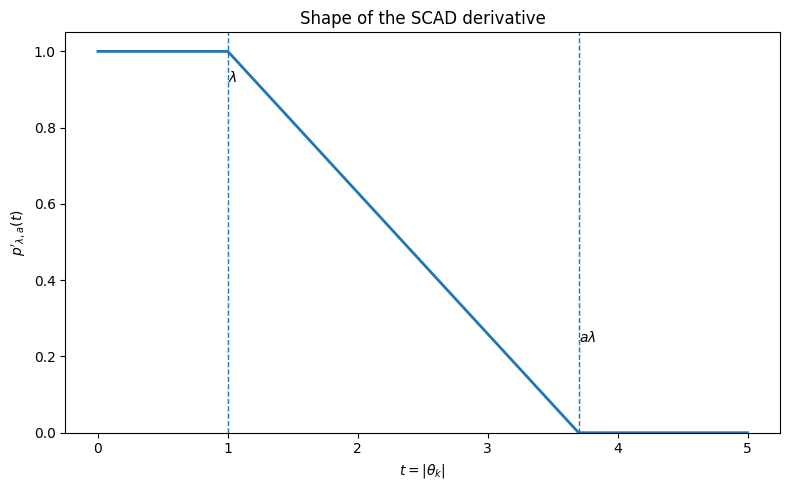

Saved:
/content/drive/MyDrive/thesis_figures/fig_scad_derivative.png
/content/drive/MyDrive/thesis_figures/fig_scad_derivative.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# SCAD derivative plot
a = 3.7
lam = 1.0

t = np.linspace(0, 5, 1000)

scad_deriv = np.where(
    t <= lam,
    lam,
    np.where(t <= a * lam, (a * lam - t) / (a - 1), 0)
)

outdir = Path("/content/drive/MyDrive/thesis_figures")
outdir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(t, scad_deriv, linewidth=2)

plt.axvline(lam, linestyle="--", linewidth=1)
plt.axvline(a * lam, linestyle="--", linewidth=1)

plt.text(lam, 0.95 * lam, r"$\lambda$", ha="left", va="top")
plt.text(a * lam, 0.25 * lam, r"$a\lambda$", ha="left", va="center")

plt.xlabel(r"$t = |\theta_k|$")
plt.ylabel(r"$p'_{\lambda,a}(t)$")
plt.title("Shape of the SCAD derivative")
plt.ylim(0, 1.05 * lam)

plt.tight_layout()

png_path = outdir / "fig_scad_derivative.png"
pdf_path = outdir / "fig_scad_derivative.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

In [ ]:
!pip -q install rpy2
%load_ext rpy2.ipython

In [ ]:
%%R
# =========================================================
# BELGIUM 2007 EXTENDED SCAD-BIC TRACEPLOT
# Small-sample illustration only
# =========================================================

if (!requireNamespace("LorenzRegression", quietly = TRUE)) {
  install.packages("LorenzRegression", repos = "https://cloud.r-project.org")
}
library(LorenzRegression)

# ---------------------------------------------------------
# 1. Read Belgium 2007 model-ready data
# ---------------------------------------------------------
d <- read.csv(
  "/content/drive/MyDrive/belgium_results/BE_2007_model_ready_with_references.csv",
  stringsAsFactors = FALSE
)

# Keep only Extended-model columns
d <- d[, c(
  "eq_income", "PB040",
  "PB150", "PB220A", "DB040", "age_group",
  "PE040", "PH010"
)]

# ---------------------------------------------------------
# 2. Clean codes
# ---------------------------------------------------------
normalize_code <- function(x) {
  y <- as.character(x)
  y <- trimws(y)
  y <- sub("\\.0$", "", y)
  y
}

cat_vars <- c("PB150", "PB220A", "DB040", "age_group", "PE040", "PH010")

for (v in cat_vars) {
  d[[v]] <- normalize_code(d[[v]])
}

d$eq_income <- as.numeric(d$eq_income)
d$PB040 <- as.numeric(d$PB040)

# ---------------------------------------------------------
# 3. Set reference categories
# ---------------------------------------------------------
levels_with_ref_first <- function(x, ref) {
  lev <- sort(unique(x[!is.na(x)]))
  if (!(ref %in% lev)) {
    stop(paste("Reference", ref, "not found"))
  }
  c(ref, lev[lev != ref])
}

d$PB150 <- factor(d$PB150, levels = levels_with_ref_first(d$PB150, "1"))
d$PB220A <- factor(d$PB220A, levels = levels_with_ref_first(d$PB220A, "BE"))
d$DB040 <- factor(d$DB040, levels = levels_with_ref_first(d$DB040, "BE10"))
d$age_group <- factor(d$age_group, levels = c("25_54", "15_24", "55_64", "65_plus"))
d$PE040 <- factor(d$PE040, levels = levels_with_ref_first(d$PE040, "1"))
d$PH010 <- factor(d$PH010, levels = levels_with_ref_first(d$PH010, "2"))

# ---------------------------------------------------------
# 4. Draw a smaller sample for illustration
# ---------------------------------------------------------
set.seed(123)

n_small <- 1500

# Use probability weights only for drawing the illustration sample
prob_w <- d$PB040 / sum(d$PB040)

idx <- sample(seq_len(nrow(d)), size = n_small, replace = FALSE, prob = prob_w)
d_small <- d[idx, ]

# Drop unused levels after subsampling
for (v in cat_vars) {
  d_small[[v]] <- droplevels(d_small[[v]])
}

# Check that each factor still has at least two observed levels
level_check <- sapply(cat_vars, function(v) nlevels(d_small[[v]]))
print(level_check)

if (any(level_check < 2)) {
  stop("At least one factor has fewer than two levels in the small sample. Increase n_small.")
}

# Normalised weights for the small sample
d_small$w_norm <- d_small$PB040 / sum(d_small$PB040)

cat("\nSmall sample size:", nrow(d_small), "\n")
cat("Weight sum:", sum(d_small$w_norm), "\n")

# ---------------------------------------------------------
# 5. Fit Extended SCAD-BIC on the small sample
# ---------------------------------------------------------
set.seed(123)

fit_ext_scad_small <- Lorenz.Reg(
  eq_income ~ PB150 + PB220A + DB040 + age_group + PE040 + PH010,
  data = d_small,
  weights = d_small$w_norm,
  penalty = "SCAD",
  na.action = na.omit
)

cat("\n=== Small-sample Extended SCAD fit ===\n")
print(fit_ext_scad_small)

cat("\n=== BIC-selected coefficients ===\n")
coef_bic_small <- coef(fit_ext_scad_small, pars.idx = "BIC", renormalize = TRUE)
print(coef_bic_small)

cat("\nNumber of nonzero BIC-selected coefficients:\n")
print(sum(abs(coef_bic_small) > 1e-10))

# ---------------------------------------------------------
# 6. Save traceplot
# ---------------------------------------------------------
outdir <- "/content/drive/MyDrive/thesis_figures"
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

png(
  filename = file.path(outdir, "fig_BE2007_extended_scad_bic_traceplot_small.png"),
  width = 1800,
  height = 1200,
  res = 200
)

plot(fit_ext_scad_small, type = "traceplot")

dev.off()

cat("\nSaved traceplot to:\n")
cat(file.path(outdir, "fig_BE2007_extended_scad_bic_traceplot_small.png"), "\n")

    PB150    PB220A     DB040 age_group     PE040     PH010 
        2         3        11         4         6         5 

Small sample size: 1500 
Weight sum: 1 

=== Small-sample Extended SCAD fit ===

Call:
Lorenz.Reg(formula = eq_income ~ PB150 + PB220A + DB040 + age_group + 
    PE040 + PH010, data = d_small, weights = d_small$w_norm, 
    na.action = na.omit, penalty = "SCAD")

Explained Gini coefficient (BIC selection method): 0.1079 

Coefficients (BIC selection method):
          PB1502          PB220AEU       PB220AOther         DB040BE21  
        -0.10299          -0.10657          -0.10657          -0.24002  
       DB040BE22         DB040BE23         DB040BE24         DB040BE25  
        -0.28606          -0.28606          -0.16960          -0.28606  
       DB040BE31         DB040BE32         DB040BE33         DB040BE34  
        -0.14496          -0.39098          -0.28606          -0.28606  
       DB040BE35    age_group15_24    age_group55_64  age_group65_plus  
     

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘warp’, ‘SparseM’, ‘MatrixModels’, ‘globals’, ‘hardhat’, ‘sparsevctrs’, ‘furrr’, ‘slider’, ‘iterators’, ‘quantreg’, ‘parsnip’, ‘rsample’, ‘doParallel’, ‘foreach’, ‘GA’, ‘Rearrangement’, ‘RcppArmadillo’

trying URL 'https://cloud.r-project.org/src/contrib/listenv_0.10.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/parallelly_1.47.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/future_1.70.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/warp_0.2.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/SparseM_1.84-2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/MatrixModels_0.5-4.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/globals_0.19.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/hardhat_1.4.3.tar.gz'
trying URL 'https://cloud.r-project.org/src/co